# Seq2Seq 모델 Q&A Chatbot 구현

1. QnA 데이터셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder, Seq2Seq(Encoder+Decoder) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다.
4. Chatbot을 만든다. (모델 추론 + while문)

In [3]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/songys/Chatbot_data/refs/heads/master/ChatbotData.csv')
df = df[['Q', 'A']]
df

,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.
...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.
11820,흑기사 해주는 짝남.,설렜겠어요.
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.


In [4]:
import json
tr_ec_inputs = []
tr_dc_inputs = []
tr_dc_targets = []
tr_data_q = []
tr_data_a = []

for k in range(1,1689):
    with open(f'TL_가족과 주거/Knowledge_가족과 주거_{k}.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        data20 = data['utterances'][:20]

        for phrase in data20:
            role = phrase['role']
            
            if role == '질문자':
                tr_ec_inputs.append(phrase['text'])
                tr_data_q.append(phrase['text'])

            elif role == '전문가':
                tr_data_a.append(phrase['text'])
                tr_dc_inputs.append('<sos>' + phrase['text'])
                tr_dc_targets.append(phrase['text'] + '<eos>')


print(f"인코더 입력 개수: {len(tr_ec_inputs)}")
print(f"디코더 입력 개수: {len(tr_dc_inputs)}")
print(f"디코더 타겟 개수: {len(tr_dc_targets)}")

인코더 입력 개수: 16880
디코더 입력 개수: 16880
디코더 타겟 개수: 16880


In [5]:
import json
val_ec_inputs = []
val_dc_inputs = []
val_dc_targets = []
val_data_q = []
val_data_a = []

for k in range(1,212):
    with open(f'VL_가족과 주거/Knowledge_가족과 주거_{k}.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        data20 = data['utterances'][:20]

        for phrase in data20:
            role = phrase['role']
            
            if role == '질문자':
                val_ec_inputs.append(phrase['text'])
                val_data_q.append(phrase['text'])

            elif role == '전문가':
                val_data_a.append(phrase['text'])
                val_dc_inputs.append('<sos>' + phrase['text'])
                val_dc_targets.append(phrase['text'] + '<eos>')


print(f"인코더 입력 개수: {len(val_ec_inputs)}")
print(f"디코더 입력 개수: {len(val_dc_inputs)}")
print(f"디코더 타겟 개수: {len(val_dc_targets)}")

인코더 입력 개수: 2110
디코더 입력 개수: 2110
디코더 타겟 개수: 2110


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [7]:
print(len(tr_ec_inputs), len(tr_dc_inputs), len(tr_dc_targets))
print(tr_ec_inputs[5000])
print(tr_dc_inputs[5000])
print(tr_dc_targets[5000])

16880 16880 16880
아기 이유식을 시작할 시기가 된 것 같은데, 언제부터 아기 이유식을 시작하면 되는 거야?
<sos>일반적으로 아기들이 생후 4~6개월 되면 이유식을 시작하는데, 이때 아기들은 몸무게는 출생 당시보다 몸무게가 2~2.5배 정도 되고 침을 흘리기 시작했을 가능성이 높아. 그리고 또, 엄마의 식사 모습을 유심히 보거나 숟가락을 입 주변에 가져가 대면서 먹으려고 하는 행동을 보이면 이유식을 시작하기 좋은 타이밍이라는 증거니까 잘 지켜보는 게 좋아.
일반적으로 아기들이 생후 4~6개월 되면 이유식을 시작하는데, 이때 아기들은 몸무게는 출생 당시보다 몸무게가 2~2.5배 정도 되고 침을 흘리기 시작했을 가능성이 높아. 그리고 또, 엄마의 식사 모습을 유심히 보거나 숟가락을 입 주변에 가져가 대면서 먹으려고 하는 행동을 보이면 이유식을 시작하기 좋은 타이밍이라는 증거니까 잘 지켜보는 게 좋아.<eos>


In [8]:
BATCH_SIZE = 64
MAX_VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
LATENT_DIM = 256

### train data 토큰화

In [9]:
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer

okt = Okt()
tr_ec_inputs = [okt.morphs(text) for text in tr_data_q]

tr_ec_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tr_ec_tokenizer.fit_on_texts(tr_ec_inputs)
tr_ec_seqs = tr_ec_tokenizer.texts_to_sequences(tr_ec_inputs)

tr_ec_num_words = MAX_VOCAB_SIZE
tr_ec_max_len = max(len(s) for s in tr_ec_seqs)

In [10]:
tokens = [okt.morphs(sent) for sent in tr_data_a]

tr_dc_input_tk= [['<sos>'] + token for token in tokens]
tr_dc_target_tk = [token + ['<eos>'] for token in tokens]

tr_dc_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tr_dc_tokenizer.fit_on_texts(tr_dc_input_tk + tr_dc_target_tk)

tr_dc_input_seqs = tr_dc_tokenizer.texts_to_sequences(tr_dc_input_tk)
tr_dc_target_seqs = tr_dc_tokenizer.texts_to_sequences(tr_dc_target_tk)

tr_dc_num_words = MAX_VOCAB_SIZE
tr_dc_max_len = max(len(s) for s in tr_dc_input_seqs)

print(f'{tr_dc_num_words = }')
print(f'{tr_dc_max_len = }')

tr_dc_num_words = 10000
tr_dc_max_len = 193


In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
tr_encoder_inputs = pad_sequences(tr_ec_seqs, maxlen=tr_ec_max_len, padding='pre')
tr_decoder_inputs = pad_sequences(tr_dc_input_seqs, maxlen=tr_dc_max_len, padding='post')
tr_decoder_targets = pad_sequences(tr_dc_target_seqs, maxlen=tr_dc_max_len, padding='post')

print(tr_encoder_inputs.shape)
print(tr_decoder_inputs.shape)
print(tr_decoder_targets.shape)

print(tr_encoder_inputs[1000])
print([tr_ec_tokenizer.index_word[s] for s in tr_encoder_inputs[1000] if s != 0])
print(tr_decoder_inputs[1000])
print([tr_dc_tokenizer.index_word[s] for s in tr_decoder_inputs[1000] if s != 0])
print(tr_decoder_targets[1000])
print([tr_dc_tokenizer.index_word[s] for s in tr_decoder_targets[1000] if s != 0])

(16880, 77)
(16880, 193)
(16880, 193)
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0   31   15  322    7   93  136
  802  135    5 5977  322  512    6  439   63    6 1786    1 5977  322
  512    3  215   63   16   87    2]
['아이', '들', '교육', '에', '대해', '고민', '하다', '보니', ',', '스팀', '교육', '정책', '을', '한다는', '말', '을', '들었어', '.', '스팀', '교육', '정책', '이', '뭘', '말', '하는', '거야', '?']
[   9 9049    8  406   13 2252    4 1662    4    4 4936    4 1811    3
   87   17    1  968    4 1336   31 2252   22 1811    2 4936   22   59
  816 1934   26   22  675 6833   17   64 6337   23    2 2159   23   31
 2693    6 4411  133   25  338  761    3   87    1    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0 

### val data 토큰화

In [12]:
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer

okt = Okt()
val_ec_inputs = [okt.morphs(text) for text in val_data_q]

val_ec_seqs = tr_ec_tokenizer.texts_to_sequences(val_ec_inputs)

val_ec_num_words = MAX_VOCAB_SIZE
val_ec_max_len = max(len(s) for s in val_ec_seqs)

In [13]:
tokens = [okt.morphs(sent) for sent in val_data_a]

val_dc_input_tk= [['<sos>'] + token for token in tokens]
val_dc_target_tk = [token + ['<eos>'] for token in tokens]

val_dc_input_seqs = tr_dc_tokenizer.texts_to_sequences(val_dc_input_tk)
val_dc_target_seqs = tr_dc_tokenizer.texts_to_sequences(val_dc_target_tk)

val_dc_num_words = MAX_VOCAB_SIZE
val_dc_max_len = max(len(s) for s in val_dc_input_seqs)

print(f'{val_dc_num_words = }')
print(f'{val_dc_max_len = }')

val_dc_num_words = 10000
val_dc_max_len = 122


In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
val_encoder_inputs = pad_sequences(val_ec_seqs, maxlen=val_ec_max_len, padding='pre')
val_decoder_inputs = pad_sequences(val_dc_input_seqs, maxlen=val_dc_max_len, padding='post')
val_decoder_targets = pad_sequences(val_dc_target_seqs, maxlen=val_dc_max_len, padding='post')

print(val_encoder_inputs.shape)
print(val_decoder_inputs.shape)
print(val_decoder_targets.shape)

print(val_encoder_inputs[1000])
print([tr_ec_tokenizer.index_word[s] for s in val_encoder_inputs[1000] if s != 0])
print(val_decoder_inputs[1000])
print([tr_dc_tokenizer.index_word[s] for s in val_decoder_inputs[1000] if s != 0])
print(val_decoder_targets[1000])
print([tr_dc_tokenizer.index_word[s] for s in val_decoder_targets[1000] if s != 0])

(2110, 69)
(2110, 122)
(2110, 122)
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0 1062  113    4  823   10    6 1584 4355  273    1]
['저출산', '문제', '가', '심각한', '것', '을', '부쩍', '느끼고', '있어요', '.']
[   9  470   19 1321   22  288   66 4396    7   58 2173  165    1    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0 

### 인코더 디코더 과정 시작

In [15]:
class HouseDataset(Dataset):
  def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
    super().__init__()
    self.encoder_inputs = encoder_inputs
    self.decoder_inputs = decoder_inputs
    self.decoder_targets = decoder_targets

  def __len__(self):
    return len(self.encoder_inputs)

  def __getitem__(self, index):
    return (
        torch.tensor(self.encoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_targets[index], dtype=torch.long),
    )

In [16]:
from torch.utils.data import DataLoader

train_dataset = HouseDataset(tr_encoder_inputs, tr_decoder_inputs, tr_decoder_targets)
val_dataset = HouseDataset(val_encoder_inputs, val_decoder_inputs, val_decoder_targets)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"{len(train_loader)}")
print(f"{len(val_loader)}")

264
33


In [17]:
class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
    self.dropout = nn.Dropout(0.3)

  def forward(self, X):
    X = self.embedding(X)
    X = self.dropout(X)
    output, (h_s, c_s) = self.lstm(X)
    return h_s, c_s

In [18]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
    self.fc = nn.Linear(latent_dim, vocab_size)
    self.dropout = nn.Dropout(0.3)

  def forward(self, X, hidden, cell):
    X = self.embedding(X)
    X = self.dropout(X)
    output, (h_s, c_s) = self.lstm(X, (hidden, cell))
    output = self.dropout(output)
    logits = self.fc(output)
    return logits, h_s, c_s

In [19]:
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, source, target):
    h_s, c_s = self.encoder(source)
    output, h_s, c_s = self.decoder(target, h_s, c_s)
    return output

In [20]:
encoder = Encoder(tr_ec_num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(tr_dc_num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)

In [21]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 100, padding_idx=0)
    (lstm): LSTM(100, 256, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 100, padding_idx=0)
    (lstm): LSTM(100, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=10000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [22]:
# !pip install torchviz

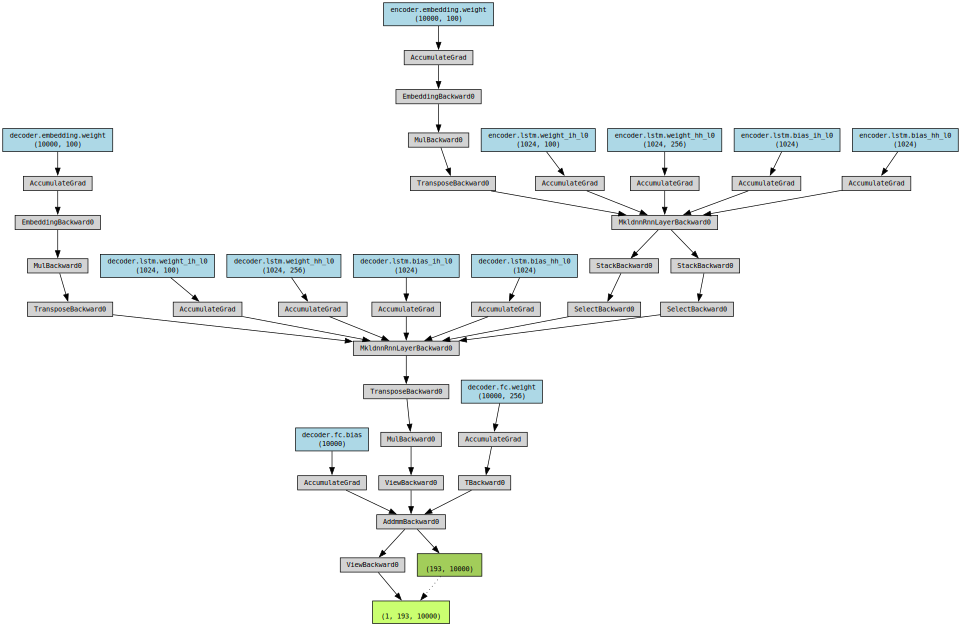

In [23]:
from torchviz import make_dot

source_input = torch.randint(0, tr_ec_num_words, (1, tr_ec_max_len))
target_input = torch.randint(0, tr_dc_num_words, (1, tr_dc_max_len))

out = model(source_input, target_input)

# make_dot(out, params=dict(list(model.named_parameters()))).render('seq2seq_torchviz', format='png')
make_dot(out, params=dict(list(model.named_parameters())))

In [24]:
# class EarlyStopping:
#     def __init__(self, patience=5, min_delta=0.001):
#         self.patience = patience
#         self.min_delta = min_delta
#         self.best_loss = float('inf')
#         self.counter = 0

#     def __call__(self, val_loss):
#         if val_loss > (self.best_loss - self.min_delta):
#             self.counter += 1
#         else:
#             self.best_loss = val_loss
#             self.counter = 0
#         return self.counter >= self.patience

In [25]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# encoder = Encoder(tr_ec_num_words, EMBEDDING_DIM, LATENT_DIM)
# decoder = Decoder(tr_dc_num_words, EMBEDDING_DIM, LATENT_DIM)
# model = Seq2Seq(encoder, decoder).to(device)

# criterion = nn.CrossEntropyLoss(ignore_index=0)
# optimizer = optim.AdamW(model.parameters(), lr=0.001)

# epochs = 100

# train_losses, train_accs, val_losses, val_accs = [], [], [], []

# for epoch in range(epochs):
#   model.train()
#   train_loss, train_correct, train_tokens = 0, 0, 0

#   for tr_ec_inputs, tr_dc_inputs, tr_dc_targets in train_loader:
#     enc_inputs = tr_ec_inputs.to(device)
#     dec_inputs = tr_dc_inputs.to(device)
#     dec_targets = tr_dc_targets.to(device)

#     optimizer.zero_grad()

#     # teacher forcing
#     output = model(enc_inputs, dec_inputs)
#     output = output.view(-1, output.size(-1))
#     dec_targets = dec_targets.view(-1)

#     loss = criterion(output, dec_targets)
#     loss.backward()
#     optimizer.step()

#     preds = output.argmax(dim=-1)
#     train_loss += loss.detach().cpu().item()
#     mask = dec_targets != 0
#     correct = (preds == dec_targets) & mask
#     train_correct += correct.sum().detach().cpu().item()
#     train_tokens += mask.sum().detach().cpu().item()

#   train_loss /= len(train_loader)
#   train_acc = train_correct / train_tokens
#   train_losses.append(train_loss)
#   train_accs.append(train_acc)

#   model.eval()
#   with torch.no_grad():
#     val_loss, val_correct, val_tokens = 0, 0, 0

#     for val_ec_inputs, val_dc_inputs, val_dc_targets in val_loader:
#       enc_inputs = val_ec_inputs.to(device)
#       dec_inputs = val_dc_inputs.to(device)
#       dec_targets = val_dc_targets.to(device)

#       output = model(enc_inputs, dec_inputs)
#       output = output.view(-1, output.size(-1))
#       dec_targets = dec_targets.view(-1)

#       loss = criterion(output, dec_targets)

#       preds = output.argmax(dim=-1)
#       val_loss += loss.detach().cpu().item()
#       mask = dec_targets != 0
#       correct = (preds == dec_targets) & mask
#       val_correct += correct.sum().detach().cpu().item()
#       val_tokens += mask.sum().detach().cpu().item()

#     val_loss /= len(val_loader)
#     val_acc = val_correct / val_tokens
#     val_losses.append(val_loss)
#     val_accs.append(val_acc)

#   print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')  

In [26]:
# import pandas as pd
# import matplotlib.pyplot as plt

# pd.DataFrame({
#     'train_loss': train_losses,
#     'val_loss': val_losses,
#     'train_acc': train_accs,
#     'val_acc': val_accs,
# }).plot()
# plt.show()

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('seq2seq_practice_model_best1.pth',weights_only=False, map_location=device)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=10000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def translate(input_seq, model, kor_tokenizer, max_len=tr_dc_max_len, device=device):
  model = model.to(device)
  model.eval()
  encoder = model.encoder
  decoder = model.decoder

  input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)

  # Encoder 처리
  with torch.no_grad():
    hidden, cell = encoder(input_seq)

  # Decoder 출력(Auto Regressive)
  sos_index = kor_tokenizer.word_index['<sos>']
  eos_index = kor_tokenizer.word_index['<eos>']

  output_sentences = []

  target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

  with torch.no_grad():
    for _ in range(max_len):
      output, hidden, cell = decoder(target_seq, hidden, cell)  # (batch_size, seq_len, vocab_size)
      proba = output.squeeze(1).softmax(dim=-1)                 # (batch_size, vocab_size)
      pred = proba.argmax(dim=-1).detach().cpu().item()

      if pred == eos_index:
        break

      if pred > 0:
        word = kor_tokenizer.index_word[pred]
        output_sentences.append(word)

      target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

  return ' '.join(output_sentences)

In [ ]:
def predict_answer(query, q_tokenizer=tr_ec_tokenizer):
    query_tokens = okt.morphs(query)
    input_seq = q_tokenizer.texts_to_sequences([query_tokens])
    input_seq = pad_sequences(input_seq, maxlen=tr_ec_max_len, padding='pre')
    return translate(input_seq, model, tr_dc_tokenizer)

while True:
    test = input("입력하세요: ")

    if test == "그만":
        print("대화를 종료합니다.")
        break

    kor = predict_answer(test)
    print(f"챗봇: {test}")
    print(f"챗봇: {kor}")
    print("----------------------------------------------------------------------")
